In [ ]:


#--LIBRARIES--------

#numerics
import numpy as np
import eelib

#visualization
#import seaborn #statistical data visualization
#import matplotlib
#import matplotlib.pyplot as plt
#from mpl_toolkits import Axes3D #projection
#import plotly.express as px #3D plot



#--CODE--

# set parameters
# note that k, B, and R are percents here, mu is not as its scale is unknown
k = 0.5
R = 0.8
B = 0.5
mu = 1.0e-7

n_k = 10
n_m = 20
n_g = 21

#m_min = 0.5
#m_max = 2
#k_min = 0.5
#k_max = 0.7
a_min = 0.5
a_max = 3.0
mu_min = 1.0e-8
mu_max = 1.0e-5

pr = 200
n = 20


#make loop, grid, or system
#loopl = eelib.loop(R, B, k, mu)#, grid_size=n_g)
#loopl = eelib.deriv_grid(R, B, k, mu, grid_size=n_g)
#gridl = parameterGrid(n_R, n_B, n_k, n_m, mu_min=mmin, mu_max=mmax, dk_max=kmax, dk_min=kmin)
gridl = eelib.grid_fast_osc(R, B, k, mu, grid_size = n_g)


# solve the ivp or bvp
#loopl.solve_ivp()
#loopl.setDeriv(-7003921000.852429+12357828925.240108j)

#maxX = n*loopl.T0
#per_range = maxX / loopl.lngt

#rtol = 2.0e-6
#atol = 1.0e-10

#sol1 = loopl.call_ivp_solver(0.0, loopl.lngt *per_range, loopl.amp, loopl.psi0_deriv_0, ee_int = True, rtol=rtol, atol=atol) # find the first n cycles
#sol2 = loopl.call_ivp_solver(0.0, loopl.lngt *per_range, loopl.amp, loopl.psi0_deriv_0, ee_int = False,rtol=rtol,atol=atol) # find the first n cycles

#loopl.solve_ivp(n = n, percent_range = pr, solve=0)
#loopl.findDeriv()
#loopl.derivGrid()
    
#loopl.saveDerivGrid()
#gridl.save_data()
#n = 2

gridl.makeGridPoints(a_min, a_max, mu_min, mu_max, num = n_k)
gridl.gridFastOsc()

# --- PLOTTING FOR GRIDS ---
#for i in range(n_g):
#    for j in range(n_g):
#        loopl.plot_abs(i,j,k,R,B,mu,n)
#        loopl.plot_real(i,j,k,R,B,mu,n)
#        plot_img(loopl,i,j,k,R,B,mu)




Begin grid build:  0.0
0 0 0.4056532382965088
0 1 35.8182487487793
0 2 69.8852744102478
0 3 103.61231255531311
0 4 137.01658821105957
0 5 171.135582447052
0 6 204.80517578125
0 7 238.6469452381134
0 8 273.8526406288147
0 9 310.0271689891815
1 0 345.6464855670929
1 1 382.4422256946564
1 2 417.6597318649292
1 3 452.220965385437
1 4 486.6857991218567
1 5 520.649097442627
1 6 554.3982610702515
1 7 588.6640625
1 8 622.8411321640015
1 9 657.264354467392
2 0 692.2049930095673
2 1 727.6726448535919
2 2 763.9333369731903
2 3 797.7231948375702
2 4 833.5114188194275
2 5 867.3280553817749
2 6 900.8014967441559
2 7 934.6285967826843
2 8 968.6515026092529
2 9 1003.5113928318024
3 0 1038.4456086158752
3 1 1070.2185623645782
3 2 1100.6802797317505
3 3 1130.5841436386108
3 4 1160.547199010849
3 5 1190.6650185585022
3 6 1220.7142820358276
3 7 1250.8681735992432
3 8 1282.3112602233887
3 9 1312.921157836914
4 0 1344.5141537189484
4 1 1375.905101299286
4 2 1410.647156238556
4 3 1445.9745421409607
4 4 1479.

In [204]:
# independent variables
#mfp = gridl.mfp
#ew = gridl.ew
nls = gridl.nls
amp = gridl.amp
dgrid = gridl.d0_grid

# dependent variables
foa = gridl.fast_osc_a
fot = gridl.fast_osc_t

In [4]:
t_1 = eelib.pi/(eelib.kFAu)

In [33]:
gridl.l_calc.k

12000312500.0

In [63]:
t_1-t_new

6.8175148511715726e-15

In [57]:
t_new  = eelib.pi/(gridl.l_calc.k)
#=eelib.pi/(eelib.kFAu+gridl.l_calc.M/4)

In [118]:
np.where(fot == np.min(fot))

(array([0], dtype=int64),
 array([0], dtype=int64),
 array([4], dtype=int64),
 array([4], dtype=int64))

In [111]:
np.min(fot)

2.617930047783228e-10

In [193]:
t_new-eelib.pi/(gridl.l_calc.k*(1+1.7e-6))

4.450466129377632e-16

In [114]:
t_1

2.6179938779233176e-10

# $\mu$ linear regression fitting

This is a straight line, find the intercept for various variants. 

Find all slopes and intercepts, then determine if it matches the expected results. ...

NameError: name 'fot' is not defined

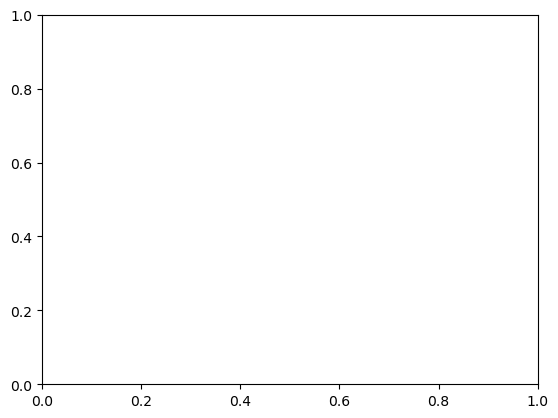

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(fot[:, 3,0,0]-t_new,nls)
plt.show()

fig, ax = plt.subplots()
ax.plot(fot[:, 4,1,1]-t_new,nls)
plt.show()

y = a x + b
y1 - y2 = a (x1 - x2)
b = y - a x

In [226]:
import scipy

In [250]:
slope = np.zeros((10,9,9))
intercept = []
r = 1
p = 0
se = 0
for i in range(10):
    for j in range(9):
        for k in range(9):
            xx = nls
            yy = fot[:, i, j, k]



            sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

            slope[i,j,k]=sl
            intercept.append(interc)

            r = min(r, r2)
            p = max(p, p2)
            se = max(se, se2)

            print(i, j, k, slope[i,j,k])

#print(1/np.average(intercept)-1/t_1)

0 0 0 1.2132617445937713e-07
0 0 1 1.1035059423128926e-07
0 0 2 9.069236493343031e-08
0 0 3 7.25222994909972e-08
0 0 4 6.51898041654335e-08
0 0 5 7.251533912861802e-08
0 0 6 9.069758234380144e-08
0 0 7 1.10353753576776e-07
0 0 8 1.2132573678894455e-07
0 1 0 1.1035562242595953e-07
0 1 1 9.938893447841554e-08
0 1 2 7.973736252180647e-08
0 1 3 6.156510315009469e-08
0 1 4 5.425445679696657e-08
0 1 5 6.156298781373555e-08
0 1 6 7.973551458243279e-08
0 1 7 9.938876025875294e-08
0 1 8 1.1035519313400065e-07
0 2 0 9.069231715107591e-08
0 2 1 7.973432165721435e-08
0 2 2 6.009854775449437e-08
0 2 3 4.194420800788763e-08
0 2 4 3.4632723889629e-08
0 2 5 4.194153951559777e-08
0 2 6 6.010224119304036e-08
0 2 7 7.973621281368304e-08
0 2 8 9.069187660170873e-08
0 3 0 7.25064106827351e-08
0 3 1 6.155983246119834e-08
0 3 2 4.193420216384994e-08
0 3 3 2.379566407289289e-08
0 3 4 1.6493070572716027e-08
0 3 5 2.379487507098096e-08
0 3 6 4.193815015841503e-08
0 3 7 6.155966869475443e-08
0 3 8 7.250619728125

In [238]:
print((1/np.average(intercept)-1/t_1)/eelib.pi)

35610.596241014005


In [245]:
np.max(slope), np.min(slope)

(4.4569576881092735e-07, 9.189162744817937e-09)

Linear dependence of mu vs t - t_0

Result for intercept, add to k: 111873.9875407219
independent of A_0 and psi'
dependent on mu (I think), but may just be numerical error (can be checked with alternative ranges of mu)
if mu dependence is numerical error, the intercept itself is numerical error, and should be zero
dependence on k, dk, and B unknown
Note that the intercept is t_0 (the period without mu)

The greatest p values are:
R2: 0.9999976281979924 
p: 1.3844923187575803e-22 
se: 3.028692221455953e-10

Previous calculations show that slope is independent of mu while intercept depends on mu. Indicates that there is a mu*f(a_0, psi'_0)+ g(mu, k, B) structure.

Slope dependent on i, j, k, but not on l1, l2. Intercept negative and becomes more negative for larger l1, l2. -10^-15 is smallest, compared to 10^-13 dt or 10^-10 t 

In [71]:
amp[2]

1.0555555555555556

In [99]:
for i in range(10):
    j = 4
    k = 4
    aa = 0
    bb = 0
    for l1 in range(9):
        for l2 in range(l1+1, 10):
            y1 = fot[l1, i,j,k]-t_new
            y2 = fot[l2, i,j,k]-t_new
            x1 = nls[l1]
            x2 = nls[l2]
            a1 = (y2-y1)/(x2-x1)
            bb += (y1 - a1 * x1)
            aa += a1
            #print( bb)
    aa = aa / 45
    bb = bb / 45 /(amp[i]**0.5-gridl.l_calc.k**0.5)
    print(i, j, k, aa, bb)

0 4 4 9.190307246078106e-09 4.4111207101012474e-21
1 4 4 2.2242025943216364e-08 4.5121708342118566e-21
2 4 4 4.098068994471871e-08 4.610309727809043e-21
3 4 4 6.538573236983115e-08 4.717878243679756e-21
4 4 4 9.550144557671534e-08 5.033514891633655e-21
5 4 4 1.3132247811588562e-07 5.083972677561858e-21
6 4 4 1.7288846359598836e-07 5.960733293219708e-21
7 4 4 2.2019410349391973e-07 6.978155713145953e-21
8 4 4 2.732369709824146e-07 8.112170805653682e-21
9 4 4 3.320957109557125e-07 1.0239829935904355e-20


Plot this with respect to mu, psi', psi
.... probably ignore this
grab the slope and average or maximum intercept
.... 


.... put in terms of k^2

In [225]:
bb = 0
for i in range(10):
    for j in range(9):
        for k in range(9):
            aa = 0
            bb = 0
            for l1 in range(9):
                for l2 in range(l1+1, 10):
                    y1 = fot[l1, i,j,k]-t_new
                    y2 = fot[l2, i,j,k]-t_new
                    x1 = nls[l1]
                    x2 = nls[l2]
                    a1 = (y2-y1)/(x2-x1)
                    b1 = (y1 - a1 * x1) #/(amp[i]*np.imag(dgrid[j,k])/gridl.l_calc.k * gridl.l_calc.M)/(nls[l1]+nls[l2])*2
                    #if b1 < bb: bb = b1
                    aa += a1
                    bb += b1
                    #print( bb)
            aa = aa / 45
            bb = bb / 45 #/amp[i]**0.5/np.abs(np.imag(dgrid[j,k]))**0.5*gridl.l_calc.k**0.5# / gridl.l_calc.M
            print(i, j, k, aa, bb)

0 0 0 1.2132618549387658e-07 -6.373549602636004e-16
0 0 1 1.1035066093613649e-07 -6.335738590078123e-16
0 0 2 9.069226542717637e-08 -6.514846270695239e-16
0 0 3 7.252286019911069e-08 -7.019119380099546e-16
0 0 4 6.518980574947992e-08 -7.536790356339024e-16
0 0 5 7.251518447885792e-08 -7.082299827579564e-16
0 0 6 9.069763556474669e-08 -6.292884818192666e-16
0 0 7 1.1035367216814157e-07 -6.4752130943143785e-16
0 0 8 1.2132574882537495e-07 -6.459498796728436e-16
0 1 0 1.1035563148378797e-07 -6.10982526340395e-16
0 1 1 9.938883924247257e-08 -6.227269692498644e-16
0 1 2 7.973732433185518e-08 -6.198355473648207e-16
0 1 3 6.156510431105402e-08 -7.24573368992989e-16
0 1 4 5.425446970128314e-08 -7.443895200389127e-16
0 1 5 6.156126462815951e-08 -7.061858705318545e-16
0 1 6 7.97355210235556e-08 -6.460005754593546e-16
0 1 7 9.938871472595934e-08 -6.379792159016876e-16
0 1 8 1.1035520219461746e-07 -6.290310854994098e-16
0 2 0 9.069232219936921e-08 -5.678542408561138e-16
0 2 1 7.97343273685039e-08 

In [218]:
t_2 = t_new - 2.12e-15
print(t_1, t_new, t_2)

2.6179938779914943e-10 2.6179257028429826e-10 2.617904502842983e-10


In [133]:
np.abs(dgrid[j,k]/gridl.l_calc.k)

1.7442017094256992

In [48]:
size = np.shape(foa.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

print(size == n_k**2 * n_g**2)

sz = [n_k * n_g **2, n_g **2, n_g, 1]

for imu in range(n_k):
    for ia in range(n_k):
        for idr in range(n_g):
            for idi in range(n_g):
                ind = imu*sz[0]+ia*sz[1]+idr*sz[2]+idi
                #npaf[ind, 0] = mfp[im]
                #npaf[ind, 1] = ew[ik]
                npaf[ind, 0] = nls[imu]
                npaf[ind, 1] = amp[ia]
                npaf[ind, 2] = np.real(dgrid[idr, idi])
                npaf[ind, 3] = np.imag(dgrid[idr, idi])
                npaf[ind, 4] = foa[imu, ia, idr, idi]
                npaf[ind, 5] = fot[imu, ia, idr, idi]

8100
True


# $A_0$ and $\Psi^\prime_0$ Regression

mu*f(a_0, psi'_0)+ g(mu, k, B)

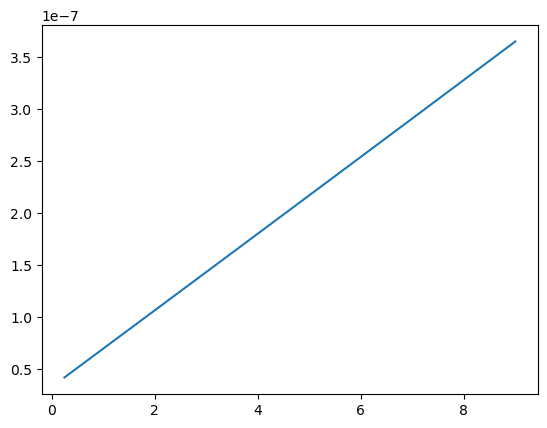

In [248]:
fig, ax = plt.subplots()
ax.plot(amp**2,slope[:,3,2])
plt.show()

#fig, ax = plt.subplots()
#ax.plot(fot[:, 4,1,1]-t_new,nls)
#plt.show()

In [ ]:
np.shape(slope)

In [266]:
slope2 = np.zeros((9,9))
intercept = np.zeros((9,9))
r = 1
p = 0
se = 0

for j in range(9):
    for k in range(9):
        xx = amp**2
        yy = slope[:,j,k]

        sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

        slope2[j,k]=sl
        intercept[j,k]=interc

        r = min(r, r2)
        p = max(p, p2)
        se = max(se, se2)

        print(j, k, slope2[j,k], intercept[j,k], r2, p2, se2)

print(np.average(slope2), r, p, se)

0 0 3.706238779934426e-08 1.1192783578301346e-07 0.9999994236138533 4.828718559384139e-25 1.4068906879123102e-11
0 1 3.704534166805134e-08 1.0095460315611467e-07 0.9999994486229488 4.0436402966811586e-25 1.3753971870392535e-11
0 2 3.701185946955667e-08 8.130333691011755e-08 0.9999994370143261 4.395083580964114e-25 1.3885443768664969e-11
0 3 3.697966459449313e-08 6.313001792726702e-08 0.9999994303765213 4.606056781116777e-25 1.3954911883019193e-11
0 4 3.696980350605955e-08 5.581097017912128e-08 0.9999994542537572 3.880974513510365e-25 1.3655660204075742e-11
0 5 3.698209691577674e-08 6.312710311045326e-08 0.9999994082053733 5.366137781267103e-25 1.4224835024670177e-11
0 6 3.7012822429754955e-08 8.13012683618937e-08 0.9999994288332126 4.6561776638093655e-25 1.3986333092592597e-11
0 7 3.704501114233206e-08 1.0095483641747446e-07 0.9999994249787145 4.783143853169455e-25 1.4045651288524832e-11
0 8 3.7064061177343986e-08 1.1192023959783252e-07 0.9999994454139308 4.1386013314466335e-25 1.38009

Slope is almost independent of psi', intercept is not.

Slope: 3.698062210078747e-08 

r: 0.9999992783744597 

p: 1.186383953629946e-24 

se:1.5713552843315777e-11

Sorce of slope in units???


In [270]:
slope_A = np.average(slope2)
(np.std(slope2))/slope_A

0.0011413280835293066

In [258]:
dgrid

array([[-1.48004277e+10-1.48004277e+10j, -1.32773111e+10-1.48004277e+10j,
        -9.97920197e+09-1.48004277e+10j, -5.34701169e+09-1.48004277e+10j,
         9.10815102e-07-1.48004277e+10j,  5.34701169e+09-1.48004277e+10j,
         9.97920197e+09-1.48004277e+10j,  1.32773111e+10-1.48004277e+10j,
         1.48004277e+10-1.48004277e+10j],
       [-1.48004277e+10-1.32773111e+10j, -1.32773111e+10-1.32773111e+10j,
        -9.97920197e+09-1.32773111e+10j, -5.34701169e+09-1.32773111e+10j,
         9.10815102e-07-1.32773111e+10j,  5.34701169e+09-1.32773111e+10j,
         9.97920197e+09-1.32773111e+10j,  1.32773111e+10-1.32773111e+10j,
         1.48004277e+10-1.32773111e+10j],
       [-1.48004277e+10-9.97920197e+09j, -1.32773111e+10-9.97920197e+09j,
        -9.97920197e+09-9.97920197e+09j, -5.34701169e+09-9.97920197e+09j,
         9.10815102e-07-9.97920197e+09j,  5.34701169e+09-9.97920197e+09j,
         9.97920197e+09-9.97920197e+09j,  1.32773111e+10-9.97920197e+09j,
         1.48004277e+10-9.97

In [271]:
intercept

array([[ 1.11927836e-07,  1.00954603e-07,  8.13033369e-08,
         6.31300179e-08,  5.58109702e-08,  6.31271031e-08,
         8.13012684e-08,  1.00954836e-07,  1.11920240e-07],
       [ 1.00956959e-07,  8.99922563e-08,  7.03502986e-08,
         5.21802809e-08,  4.48722923e-08,  5.21798927e-08,
         7.03450785e-08,  8.99914412e-08,  1.00952499e-07],
       [ 8.12879227e-08,  7.03414158e-08,  5.07175481e-08,
         3.25631232e-08,  2.52608867e-08,  3.25647973e-08,
         5.07174058e-08,  7.03363076e-08,  8.12918138e-08],
       [ 6.31131182e-08,  5.21707630e-08,  3.25579093e-08,
         1.44214454e-08,  7.12771561e-09,  1.44213111e-08,
         3.25530812e-08,  5.21706776e-08,  6.31108559e-08],
       [ 5.57895435e-08,  4.48501137e-08,  2.52462822e-08,
         7.11316689e-09, -1.77089079e-10,  7.11262285e-09,
         2.52483575e-08,  4.48441268e-08,  5.57827438e-08],
       [ 6.30969096e-08,  5.21549752e-08,  3.25416272e-08,
         1.44110065e-08,  7.10921468e-09,  1.440660

In [259]:
dlist = np.real(dgrid[1])

In [317]:
dlist

array([-1.48004277e+10, -1.32773111e+10, -9.97920197e+09, -5.34701169e+09,
        9.10815102e-07,  5.34701169e+09,  9.97920197e+09,  1.32773111e+10,
        1.48004277e+10])

In [277]:
dgrid.flatten

<function ndarray.flatten>

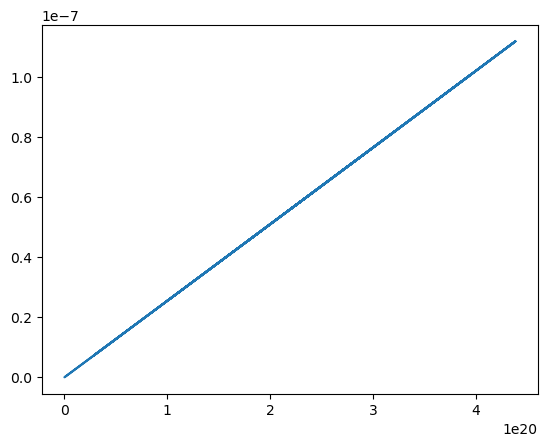

In [278]:
fig, ax = plt.subplots()
ax.plot(np.abs(dgrid.flatten())**2,intercept.flatten())
plt.show()

Already not so clear. Error is visible.

In [280]:
t_0

2.6179938779914943e-10

In [288]:

xx = np.abs(dgrid.flatten())**2
yy = intercept.flatten()

sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

print(sl/t_new**2*eelib.pi**2, interc, r2, p2, se2)


3.684629814908236e-08 -2.4101818917415576e-10 0.9999995608272387 5.3275998386601804e-241 2.697913640771045e-32


R values still good. Slope close to A_0 slope, as it should be, but closer if -intercept is added. Assume no intercept and A_0 slope is correct for (psi'_0 / k)^2 I still don't know what the A_0 slope comes from. I need to check my constants. 

In [299]:
eelib.pi**2

9.869604401089358

In [303]:
print(eelib.pppterm/eelib.kFAu**3)

3.120029521219027e-08


In [295]:
slope_A

3.698062210078747e-08

In [382]:
slope_d = 3.684629814908236e-08

In [289]:
-2.4101818917415576e-10/ 3.698062210078747e-08

-0.006517418460870714

In [291]:
3.684629814908236e-08+2.4101818917415576e-10

3.7087316338256514e-08

In [286]:
slope_A

3.698062210078747e-08

In [ ]:
for j in range(9):
    for k in range(9):
        sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

# mu intercept term

In [473]:
f_dt_A2 = np.zeros((10,10,9,9))
g_fun = np.zeros((10,10,9,9))
for nn in range(10): 
    for ii in range(10):
        for jj in range(9):
            for kk in range(9):
                f_dt_A2[nn,ii,jj,kk] = (slope_A*nls[nn]*(amp[ii]**2)+slope_A*nls[nn]*((np.abs(dgrid[jj,kk])*t_new/eelib.pi)**2))-4e-16
                g_fun[nn,ii,jj,kk] = fot[nn,ii,jj,kk] - t_new - f_dt_A2[nn,ii,jj,kk]

In [461]:
t_0-t_new

6.8175148511715726e-15

In [421]:
nls

array([2.00e-08, 2.40e-07, 4.60e-07, 6.80e-07, 9.00e-07, 1.12e-06,
       1.34e-06, 1.56e-06, 1.78e-06, 2.00e-06])

In [425]:
np.log(1e-6)/np.log(nls)

array([0.77932503, 0.90637333, 0.94678408, 0.97284291, 0.99243147,
       1.00827085, 1.02164261, 1.03325792, 1.04355449, 1.05282182])

In [352]:
slope_A-0.001e-8

3.697062210078747e-08

In [347]:
t_new

2.6179257028429826e-10

In [362]:
np.max(fot)-t_new

8.906833868162241e-13

In [361]:
np.min(fot)-t_new

-4.554855587525055e-16

In [462]:
np.max(g_fun)

2.4362792769458473e-17

In [409]:
np.min(g_fun)

-2.0977047266246725e-15

In [326]:
np.min(g_fun)

-2.325207011597883e-15

In [336]:
dgrid[0, 4]

(9.108151018871715e-07-14800427695.672611j)

Real

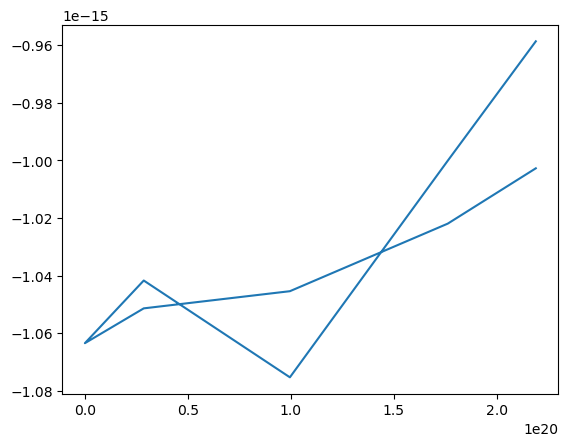

In [464]:
fig, ax = plt.subplots()
ax.plot(abs(dlist)**2, g_fun[1, 1,0,:])
plt.show()

Imag

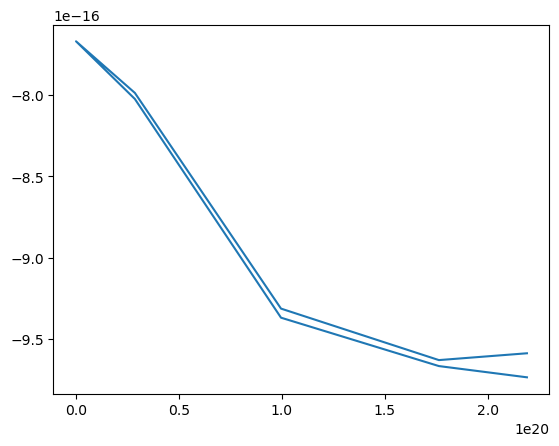

In [465]:
fig, ax = plt.subplots()
ax.plot(abs(dlist)**2, g_fun[1, 1,:,0])
plt.show()

Amp

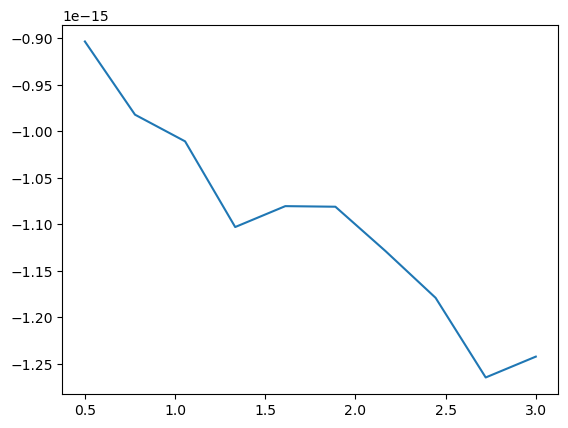

In [466]:
fig, ax = plt.subplots()
ax.plot(amp, g_fun[1, :,2,2])
plt.show()

Mu

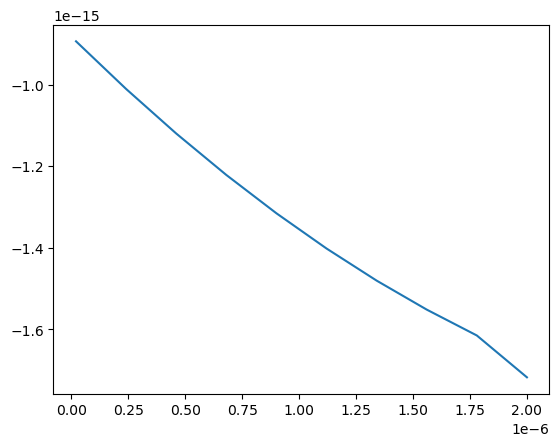

In [469]:
fig, ax = plt.subplots()
ax.plot(nls, g_fun[:, 2,2,2])
plt.show()

In [397]:
xx = nls
yy = g_fun[:, 2,2,2]
sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)
print(sl, interc, r2, p2, se2)

-4.038410279956956e-10 -7.249849279853184e-16 -0.9963132308092928 8.047096023541774e-10 1.2294386583127035e-11


Real and imaginary derivative part have opposite signs. I need more data points for the derivitive. Perhaps part needs to be added to the first term. 

In [474]:
size = np.shape(foa.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

print(size == n_k**2 * n_g**2)

sz = [n_k * n_g **2, n_g **2, n_g, 1]

for imu in range(n_k):
    for ia in range(n_k):
        for idr in range(n_g):
            for idi in range(n_g):
                ind = imu*sz[0]+ia*sz[1]+idr*sz[2]+idi
                #npaf[ind, 0] = mfp[im]
                #npaf[ind, 1] = ew[ik]
                npaf[ind, 0] = nls[imu]
                npaf[ind, 1] = amp[ia]
                npaf[ind, 2] = np.real(dgrid[idr, idi])
                npaf[ind, 3] = np.imag(dgrid[idr, idi])
                npaf[ind, 4] = foa[imu, ia, idr, idi]
                npaf[ind, 5] = g_fun[imu, ia, idr, idi]

8100
True


# Triangle plots

In [475]:
import pandas as pd

dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "T fast"])

In [405]:
dfa[dfa['mu'] > 1.1e-7]

,mu,A0,D re,D im,A max,T fast
810,2.400000e-07,0.5,-1.480043e+10,-1.480043e+10,1.781350,-6.509787e-16
811,2.400000e-07,0.5,-1.327731e+10,-1.480043e+10,1.692092,-6.663704e-16
812,2.400000e-07,0.5,-9.979202e+09,-1.480043e+10,1.515825,-6.906093e-16
813,2.400000e-07,0.5,-5.347012e+09,-1.480043e+10,1.324093,-7.673242e-16
814,2.400000e-07,0.5,9.108151e-07,-1.480043e+10,1.233548,-8.035133e-16
...,...,...,...,...,...,...
8095,2.000000e-06,3.0,9.108151e-07,1.480043e+10,3.000000,-1.795579e-15
8096,2.000000e-06,3.0,5.347012e+09,1.480043e+10,3.039669,-1.583873e-15
8097,2.000000e-06,3.0,9.979202e+09,1.480043e+10,3.134461,-1.112260e-15
8098,2.000000e-06,3.0,1.327731e+10,1.480043e+10,3.231828,-6.524387e-16


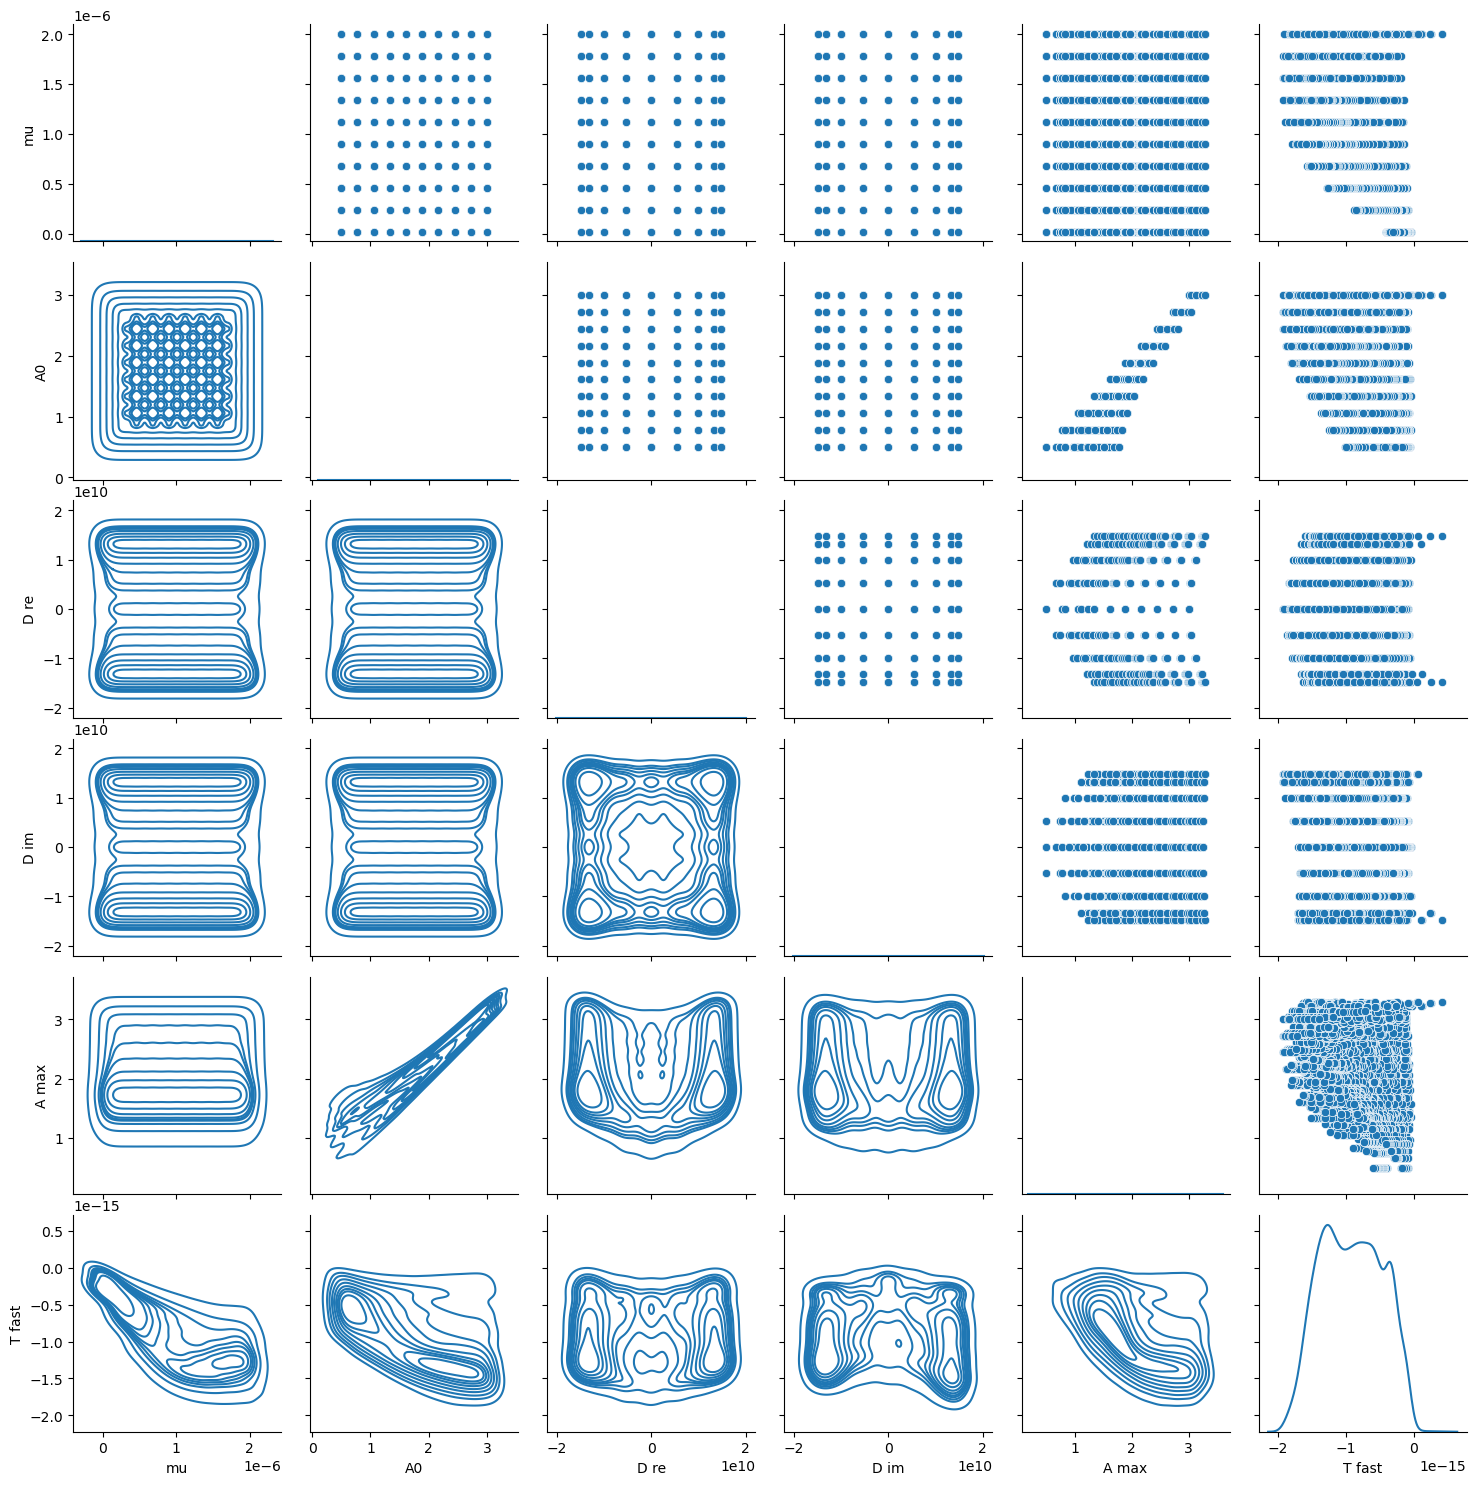

In [476]:
#visualization
import seaborn as sns #statistical data visualization
#import matplotlib
#import matplotlib.pyplot as plt
#from mpl_toolkits import Axes3D #projection
#import plotly.express as px #3D plot



g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

#g.map_diag(sns.histplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot)

In [10]:
t_0 = eelib.pi/eelib.kFAu

In [11]:
t_0

2.6179938779914943e-10

In [477]:
#t_0 = eelib.pi/eelib.kFAu
#npaf[:,-1]= npaf[:,-1]-t_new
#npaf[:,-1]= npaf[:,-1] / npaf[:,0]
npaf[:,0]=np.log(npaf[:,0])
#npaf[:,2]=np.power(npaf[:,2],2)
#npaf[:,3]=np.power(npaf[:,3],2)

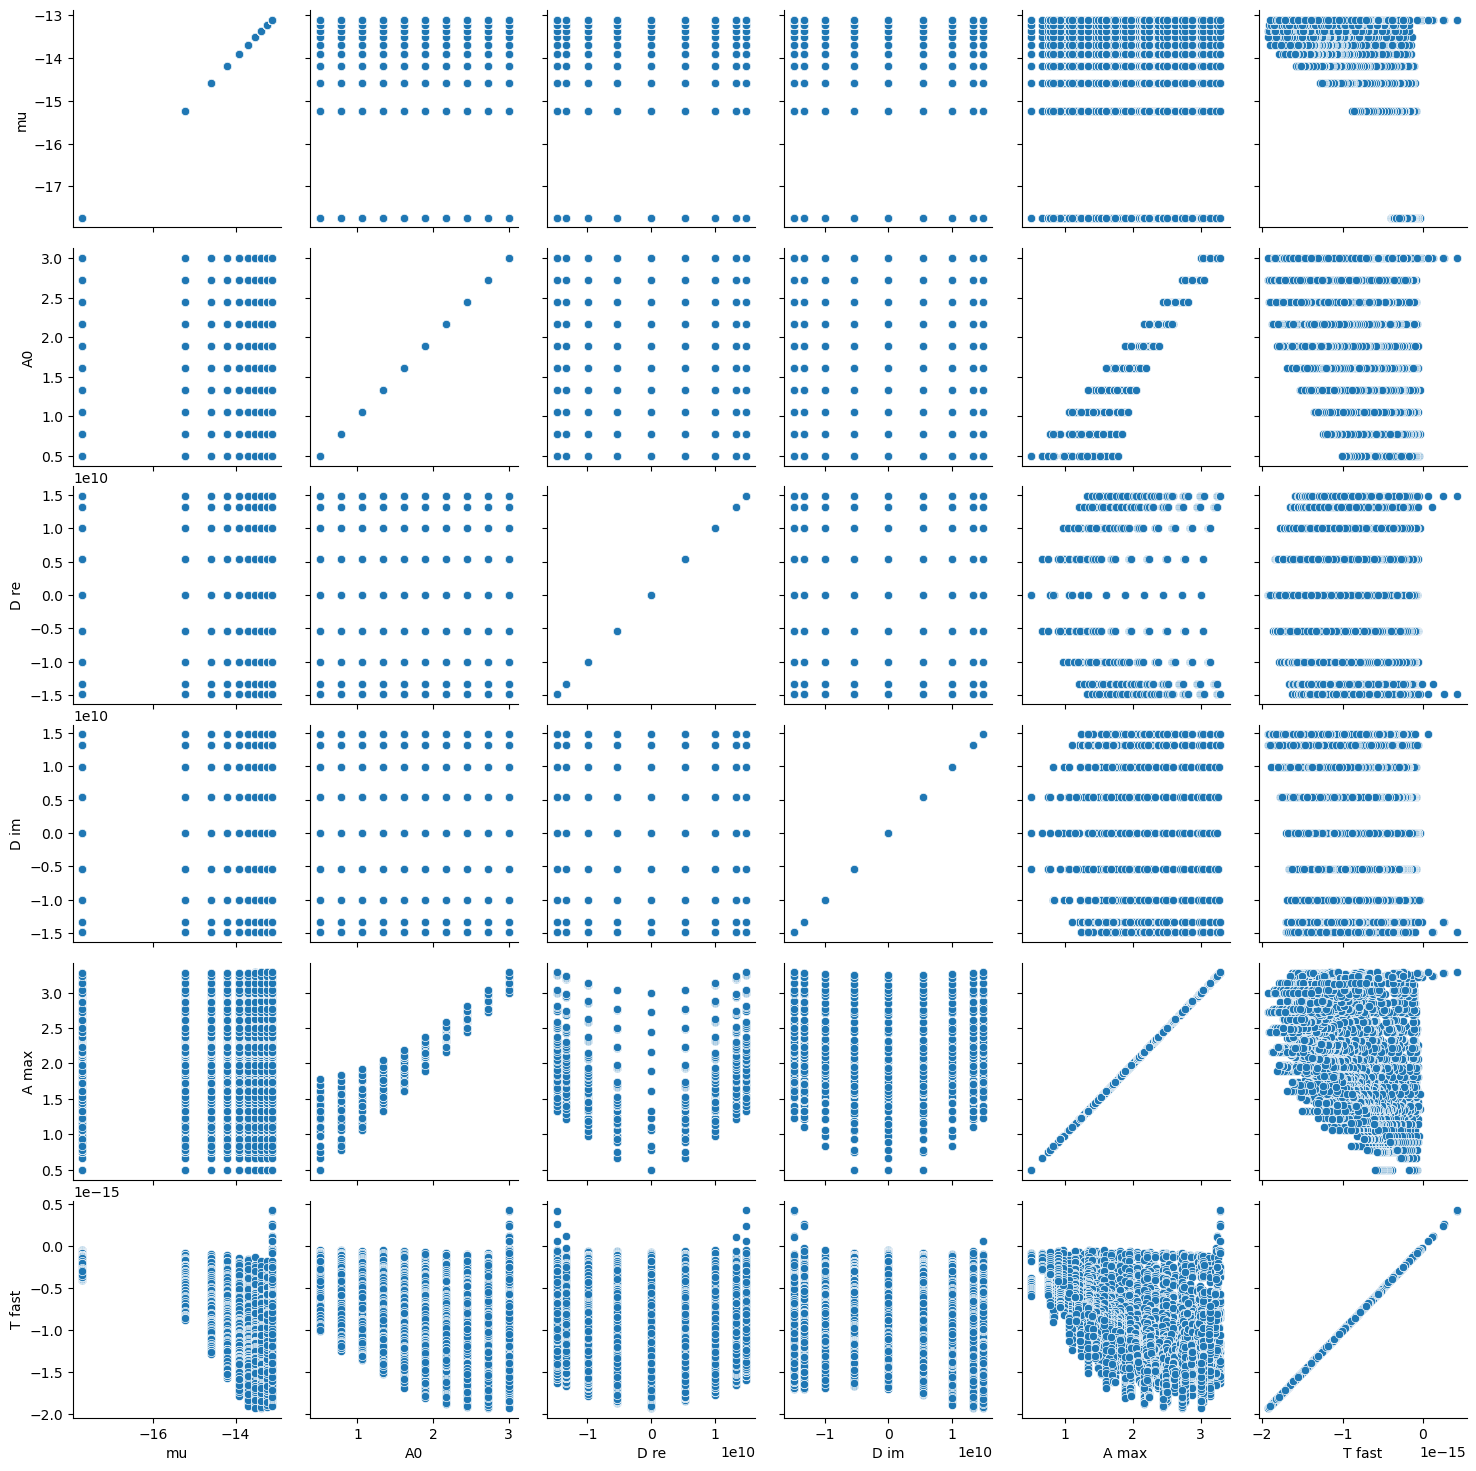

In [478]:
#dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "T fast"])

g = sns.PairGrid(dfa)
g.map(sns.scatterplot)

In [ ]:
npaf[:,2]

In [51]:
npaf[:,-1]= npaf[:,-1] *npaf[:,1]*npaf[:,1]

In [80]:
npaf[:,0]=np.power(npaf[:,0],2)

In [72]:
npaf[:,3]=np.power(npaf[:,3],2)